<a href="https://colab.research.google.com/github/misbakhulfajar27-killertheriper/Tugas_1/blob/main/Tugas_1_mechinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_tugas1_preprocessing.csv to dataset_tugas1_preprocessing.csv


In [2]:
# TAHAP 1: LOAD DATASET
# Nama : MISBAKHUL FAJAR  |  NIM : 047996694

# Mengimpor library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Membaca dataset ke DataFrame
df = pd.read_csv('dataset_tugas1_preprocessing.csv')

# Menampilkan 5 baris pertama
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


In [3]:
# TAHAP 2: EKSPLORASI AWAL (EDA)

# 2.1 Menampilkan ukuran dan tipe data
print("Jumlah baris dan kolom:", df.shape)
df.info()

# 2.2 Menghitung nilai hilang per kolom
print("\nJumlah nilai hilang:")
print(df.isnull().sum())

# 2.3 Menyajikan statistik deskriptif
print("\nStatistik numerik:")
print(df.describe())
print("\nStatistik kategorikal:")
print(df.describe(include='object'))

Jumlah baris dan kolom: (99, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB

Jumlah nilai hilang:
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64

Statistik numerik:
            Umur
count  90.000000
mean   23.366667
std     3.763963
min    18.000000
25%    20.000000
50%    23.000000
75%    26.000000
max    30.000000

Stati

In [4]:
# TAHAP 3: MENANGANI MISSING VALUES

# Mengisi Umur (numerik) dengan median
df['Umur'] = df['Umur'].fillna(df['Umur'].median())

# Mengisi Nilai_Akhir (kategorikal) dengan modus
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])

# Memastikan tidak ada nilai hilang
print(df.isnull().sum())

ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


In [5]:
# TAHAP 4: NORMALISASI FORMAT TANGGAL

# Mengonversi format yyyy/mm/dd
tgl_1 = pd.to_datetime(df['Tanggal_Ujian'], format='%Y/%m/%d', errors='coerce')

# Mengonversi format dd-mm-yyyy
tgl_2 = pd.to_datetime(df['Tanggal_Ujian'], format='%d-%m-%Y', errors='coerce')

# Menggabungkan kedua hasil konversi
df['Tanggal_Ujian'] = tgl_1.fillna(tgl_2)

# Memastikan tipe datetime dan tidak ada yang gagal konversi
print("Tipe data:", df['Tanggal_Ujian'].dtype)
print("Gagal konversi:", df['Tanggal_Ujian'].isnull().sum())

Tipe data: datetime64[ns]
Gagal konversi: 0


In [6]:
# TAHAP 5: ENCODING LABEL

# Menyalin data agar df asli tetap berisi teks
df_encoded = df.copy()

# Menentukan kolom kategorikal
kolom_kategorikal = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

# Mengubah label menjadi angka dan menyimpan encoder
encoders = {}
for kolom in kolom_kategorikal:
    le = LabelEncoder()
    df_encoded[kolom] = le.fit_transform(df_encoded[kolom])
    encoders[kolom] = le

# Menampilkan pemetaan label ke angka
for kolom in kolom_kategorikal:
    print(f"Pemetaan {kolom}:")
    for angka, label in enumerate(encoders[kolom].classes_):
        print(f"   {label} -> {angka}")

# Memastikan hasil encoding
print("\n", df_encoded.dtypes)
df_encoded.head()

Pemetaan Nama:
   Adi -> 0
   Budi -> 1
   Citra -> 2
   Dina -> 3
   Eka -> 4
   Farhan -> 5
   Gita -> 6
   Hana -> 7
   Iwan -> 8
   Joko -> 9
Pemetaan Jenis_Kelamin:
   Laki-laki -> 0
   Perempuan -> 1
Pemetaan Prodi:
   Data Science -> 0
   Informatika -> 1
   Sistem Informasi -> 2
   Teknik Komputer -> 3
Pemetaan Status:
   Aktif -> 0
   Cuti -> 1
   DO -> 2
   Lulus -> 3
Pemetaan Nilai_Akhir:
   A -> 0
   B -> 1
   C -> 2
   D -> 3
   E -> 4

 ID                       object
Nama                      int64
Jenis_Kelamin             int64
Prodi                     int64
Status                    int64
Nilai_Akhir               int64
Tanggal_Ujian    datetime64[ns]
Umur                    float64
dtype: object


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


In [7]:
# TAHAP 6: SPLIT DATA (80% LATIH - 20% UJI)

# Membagi data dengan random_state agar hasil konsisten
data_latih, data_uji = train_test_split(df_encoded, test_size=0.2, random_state=42)

# Memastikan ukuran hasil split
print("Total data :", len(df_encoded))
print("Data latih :", len(data_latih))
print("Data uji   :", len(data_uji))

Total data : 99
Data latih : 79
Data uji   : 20


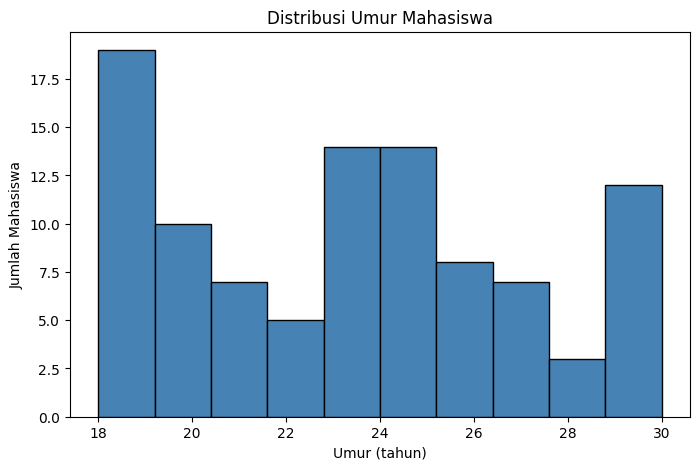

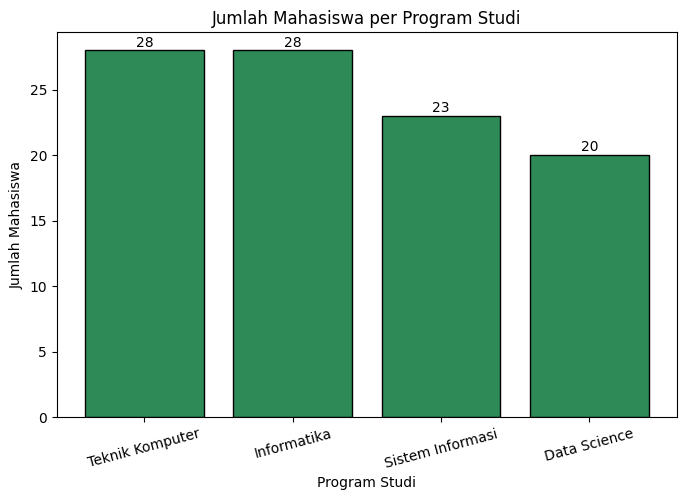

In [8]:
# TAHAP 7: VISUALISASI

# 7.1 Membuat histogram Umur
plt.figure(figsize=(8, 5))
plt.hist(df['Umur'], bins=10, color='steelblue', edgecolor='black')
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur (tahun)')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

# 7.2 Membuat grafik batang jumlah mahasiswa per Prodi
jumlah_prodi = df['Prodi'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(jumlah_prodi.index, jumlah_prodi.values, color='seagreen', edgecolor='black')

# Menampilkan angka di atas batang
for i, nilai in enumerate(jumlah_prodi.values):
    plt.text(i, nilai + 0.3, str(nilai), ha='center')

plt.title('Jumlah Mahasiswa per Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=15)
plt.show()